In [1]:
import pandas, numpy

In [2]:
import scipy, scipy.signal

In [3]:
import matplotlib, matplotlib.pyplot
matplotlib.rcParams.update({'font.size':20, 
                            'font.family':'sans-serif', 
                            'xtick.labelsize':16, 
                            'ytick.labelsize':16, 
                            'figure.figsize':(16*(2/3), 9*(2/3)), 
                            'axes.labelsize':20
                           })

In [4]:
df = pandas.read_csv('xResults_so_Linda_des12.tsv', sep='\t', index_col=0)
df

,ensembl_gene_id,full_name,biotype,gene_symbol,pval,qval,estimate,siC_1,siC_2,siC_3,siFGD5ASI_1,siFGD5ASI_2,siFGD5ASI_3
target_id,,,,,,,,,,,,,
ENST00000000233.10,ENSG00000004059,ADP ribosylation factor 5 [Source:HGNC Symbol;...,protein_coding,ARF5,0.418343,0.889708,-0.003194,87.766909,73.221945,70.745513,85.444978,7.708075e+01,67.633311
ENST00000000412.8,ENSG00000003056,"mannose-6-phosphate receptor, cation dependent...",protein_coding,M6PR,0.147451,0.832985,-0.165312,103.319681,80.301841,94.891389,85.198622,8.565988e+01,66.662304
ENST00000000442.11,ENSG00000173153,estrogen related receptor alpha [Source:HGNC S...,protein_coding,ESRRA,1.000000,1.000000,-0.033781,6.873487,5.869429,5.219480,4.613383,7.236326e+00,5.775739
ENST00000001008.6,ENSG00000004478,FKBP prolyl isomerase 4 [Source:HGNC Symbol;Ac...,protein_coding,FKBP4,0.120775,0.799312,-0.178706,69.280262,69.961465,70.236002,51.860689,7.179164e+01,54.568755
ENST00000001146.7,ENSG00000003137,cytochrome P450 family 26 subfamily B member 1...,protein_coding,CYP26B1,0.716668,0.927770,-0.253453,0.346298,0.107093,0.302926,0.157792,2.033180e-01,0.166680
...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENST00000696884.1,ENSG00000140968,interferon regulatory factor 8 [Source:HGNC Sy...,nonsense_mediated_decay,IRF8,0.142449,0.827582,-1.706226,0.320264,0.176745,0.076286,0.126458,5.902033e-02,0.000000
ENST00000696886.1,ENSG00000140968,interferon regulatory factor 8 [Source:HGNC Sy...,retained_intron,IRF8,0.510731,0.900384,0.689853,0.000000,0.026601,0.023860,0.010933,2.255272e-02,0.032144
ENST00000696893.1,NaN,NaN,NaN,NaN,0.122096,0.801774,0.372676,3.746492,3.009481,2.839653,3.525384,5.622792e+00,5.012313


In [5]:
df['control'] = numpy.median(df.iloc[:, 7:10], axis=1)
df['si'] = numpy.median(df.iloc[:, 10:13], axis=1)
df['median'] = numpy.median(df.iloc[:, 13:15], axis=1)
df['max'] = numpy.max(df.iloc[:, 13:15], axis=1)
df

,ensembl_gene_id,full_name,biotype,gene_symbol,pval,qval,estimate,siC_1,siC_2,siC_3,siFGD5ASI_1,siFGD5ASI_2,siFGD5ASI_3,control,si,median,max
target_id,,,,,,,,,,,,,,,,,
ENST00000000233.10,ENSG00000004059,ADP ribosylation factor 5 [Source:HGNC Symbol;...,protein_coding,ARF5,0.418343,0.889708,-0.003194,87.766909,73.221945,70.745513,85.444978,7.708075e+01,67.633311,73.221945,77.080747,75.151346,77.080747
ENST00000000412.8,ENSG00000003056,"mannose-6-phosphate receptor, cation dependent...",protein_coding,M6PR,0.147451,0.832985,-0.165312,103.319681,80.301841,94.891389,85.198622,8.565988e+01,66.662304,94.891389,85.198622,90.045006,94.891389
ENST00000000442.11,ENSG00000173153,estrogen related receptor alpha [Source:HGNC S...,protein_coding,ESRRA,1.000000,1.000000,-0.033781,6.873487,5.869429,5.219480,4.613383,7.236326e+00,5.775739,5.869429,5.775739,5.822584,5.869429
ENST00000001008.6,ENSG00000004478,FKBP prolyl isomerase 4 [Source:HGNC Symbol;Ac...,protein_coding,FKBP4,0.120775,0.799312,-0.178706,69.280262,69.961465,70.236002,51.860689,7.179164e+01,54.568755,69.961465,54.568755,62.265110,69.961465
ENST00000001146.7,ENSG00000003137,cytochrome P450 family 26 subfamily B member 1...,protein_coding,CYP26B1,0.716668,0.927770,-0.253453,0.346298,0.107093,0.302926,0.157792,2.033180e-01,0.166680,0.302926,0.166680,0.234803,0.302926
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENST00000696884.1,ENSG00000140968,interferon regulatory factor 8 [Source:HGNC Sy...,nonsense_mediated_decay,IRF8,0.142449,0.827582,-1.706226,0.320264,0.176745,0.076286,0.126458,5.902033e-02,0.000000,0.176745,0.059020,0.117883,0.176745
ENST00000696886.1,ENSG00000140968,interferon regulatory factor 8 [Source:HGNC Sy...,retained_intron,IRF8,0.510731,0.900384,0.689853,0.000000,0.026601,0.023860,0.010933,2.255272e-02,0.032144,0.023860,0.022553,0.023206,0.023860
ENST00000696893.1,NaN,NaN,NaN,NaN,0.122096,0.801774,0.372676,3.746492,3.009481,2.839653,3.525384,5.622792e+00,5.012313,3.009481,5.012313,4.010897,5.012313


14.296226562656594


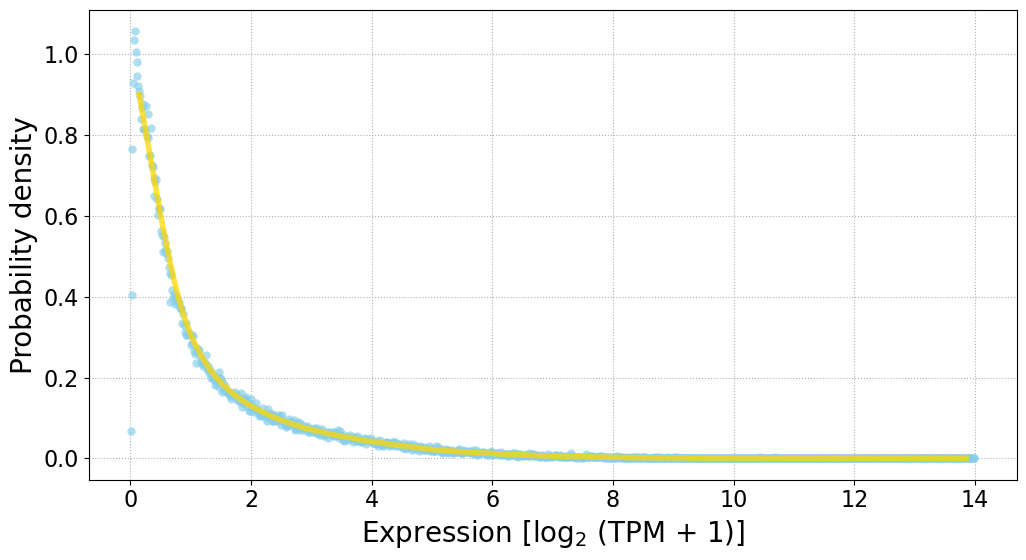

In [6]:
log_expression = numpy.log2(df['median'] + 1) 

number_of_bins = 1000
found_max = numpy.max(log_expression)
print(found_max)
found_max = 14

hist, bin_edges = numpy.histogram(log_expression, bins=number_of_bins, range=(0, found_max), density=True)
half_bin = (bin_edges[1] - bin_edges[0])/2
x = bin_edges + half_bin
x = x[:-1]

matplotlib.pyplot.plot(x, hist, 'o', alpha=2/3, mec='none', color='skyblue')

margin = 10
plotting_x = x[margin:number_of_bins-margin]
plotting_hist = hist[margin:number_of_bins-margin]

yhat = scipy.signal.savgol_filter(plotting_hist, 51, 1)
matplotlib.pyplot.plot(plotting_x, yhat, '-', lw=4, alpha=3/4, color='gold')

matplotlib.pyplot.xlabel('Expression [log$_2$ (TPM + 1)]')
matplotlib.pyplot.ylabel('Probability density')
matplotlib.pyplot.grid(ls=':')

matplotlib.pyplot.tight_layout()

14.476870834980316


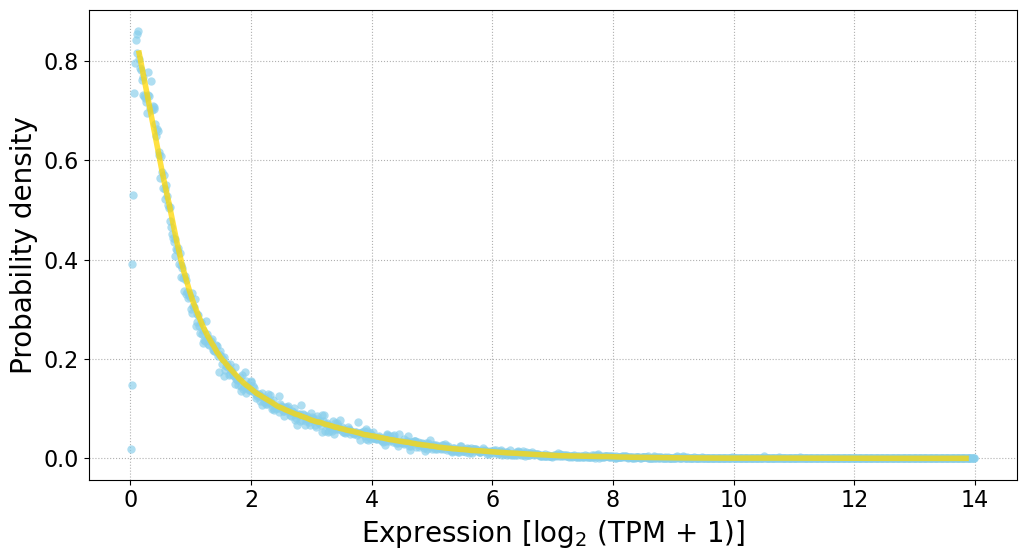

In [7]:
log_expression = numpy.log2(df['max'] + 1)

number_of_bins = 1000
found_max = numpy.max(log_expression)
print(found_max)
found_max = 14

hist, bin_edges = numpy.histogram(log_expression, bins=number_of_bins, range=(0, found_max), density=True)
half_bin = (bin_edges[1] - bin_edges[0])/2
x = bin_edges + half_bin
x = x[:-1]

matplotlib.pyplot.plot(x, hist, 'o', alpha=2/3, mec='none', color='skyblue')

margin = 10
plotting_x = x[margin:number_of_bins-margin]
plotting_hist = hist[margin:number_of_bins-margin]

yhat = scipy.signal.savgol_filter(plotting_hist, 51, 1)
matplotlib.pyplot.plot(plotting_x, yhat, '-', lw=4, alpha=3/4, color='gold')

matplotlib.pyplot.xlabel('Expression [log$_2$ (TPM + 1)]')
matplotlib.pyplot.ylabel('Probability density')
matplotlib.pyplot.grid(ls=':')

matplotlib.pyplot.tight_layout()

14.476870834980316


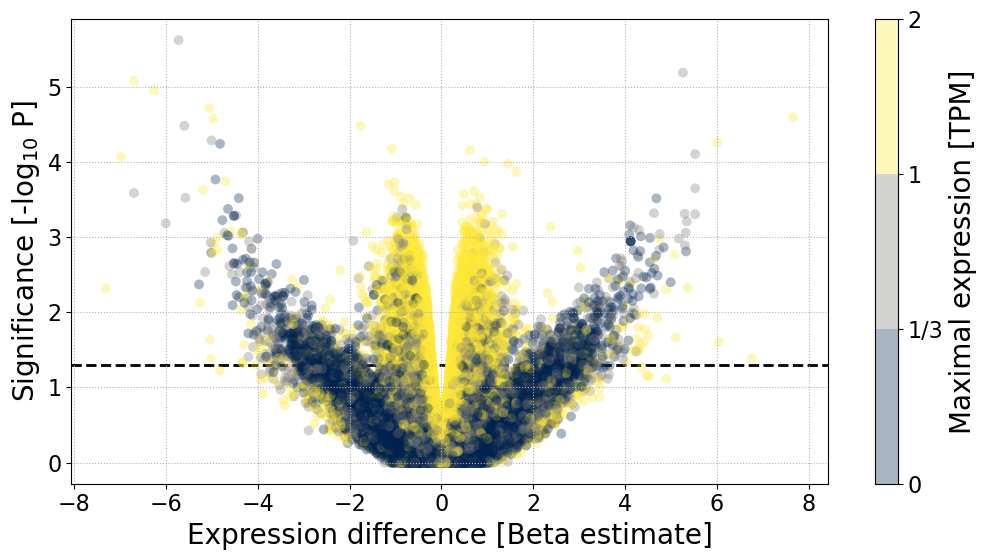

In [8]:
x = df['estimate']
y1 = -numpy.log10(df['pval'])
y2 = -numpy.log10(df['qval'])
z = numpy.log2(df['max'] + 1) 

print(max(z))

bounds = [0, numpy.log2(1/3 + 1), numpy.log2(1 + 1), numpy.log2(2 + 1)]
norm = matplotlib.colors.BoundaryNorm(boundaries=bounds, ncolors=256)

matplotlib.pyplot.scatter(x, y1, s=50, c=z, marker='o', cmap='cividis', alpha=1/3, edgecolors='none', norm=norm)

cbar = matplotlib.pyplot.colorbar(label='Maximal expression [TPM]')
cbar.ax.set_yticklabels(['0', '1/3', '1', '2'])

#matplotlib.pyplot.colorbar(matplotlib.cm.ScalarMappable(cmap=volcano.get_cmap()), ax=matplotlib.pyplot.gca())

matplotlib.pyplot.axhline(y=-numpy.log10(0.05), lw=2, ls='--', color='black', zorder=0)

matplotlib.pyplot.xlabel('Expression difference [Beta estimate]')
matplotlib.pyplot.ylabel('Significance [-log$_{10}$ P]')
matplotlib.pyplot.grid(ls=':', zorder=0)
matplotlib.pyplot.tight_layout()
matplotlib.pyplot.show()

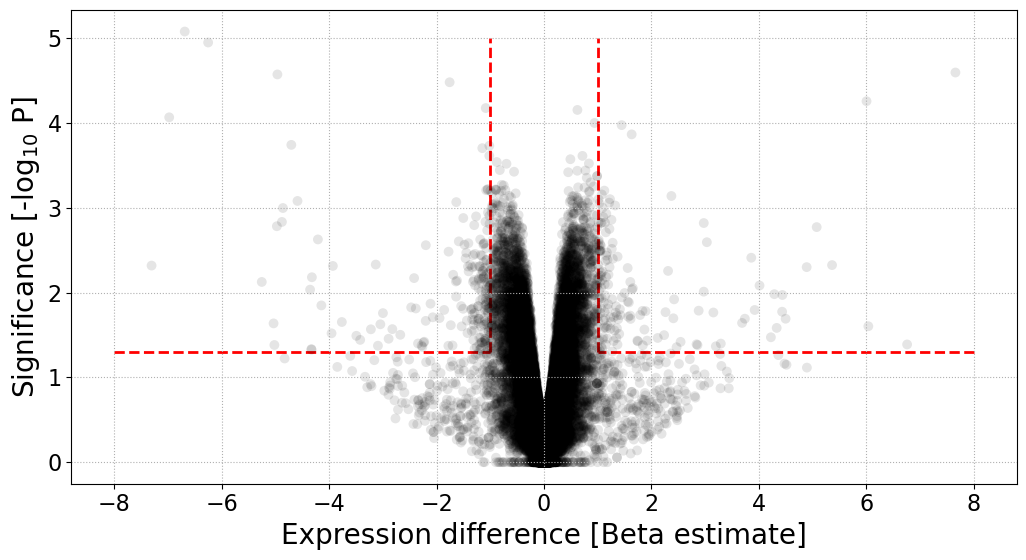

In [9]:
wdf = df[df['max'] > 2]

x = wdf['estimate']
y = -numpy.log10(wdf['pval'])
matplotlib.pyplot.scatter(x, y, s=50, c='black', marker='o', alpha=1/10, edgecolors='none')

matplotlib.pyplot.plot([-8, -1], [-numpy.log10(0.05), -numpy.log10(0.05)], lw=2, ls='--', color='red', zorder=0)
matplotlib.pyplot.plot([8, 1], [-numpy.log10(0.05), -numpy.log10(0.05)], lw=2, ls='--', color='red', zorder=0)
matplotlib.pyplot.plot([-1, -1], [-numpy.log10(0.05), 5], lw=2, ls='--', color='red', zorder=0)
matplotlib.pyplot.plot([1, 1], [-numpy.log10(0.05), 5], lw=2, ls='--', color='red', zorder=0)

matplotlib.pyplot.xlabel('Expression difference [Beta estimate]')
matplotlib.pyplot.ylabel('Significance [-log$_{10}$ P]')
matplotlib.pyplot.grid(ls=':', zorder=0)
matplotlib.pyplot.tight_layout()
matplotlib.pyplot.show()

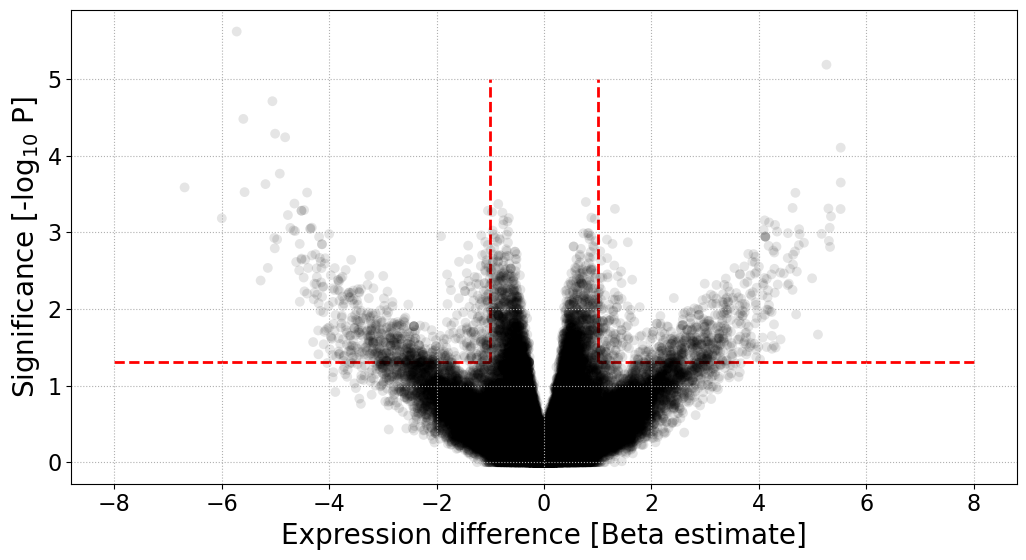

In [10]:
wdf = df[df['max'] < 2]

x = wdf['estimate']
y = -numpy.log10(wdf['pval'])
matplotlib.pyplot.scatter(x, y, s=50, c='black', marker='o', alpha=1/10, edgecolors='none')

matplotlib.pyplot.plot([-8, -1], [-numpy.log10(0.05), -numpy.log10(0.05)], lw=2, ls='--', color='red', zorder=0)
matplotlib.pyplot.plot([8, 1], [-numpy.log10(0.05), -numpy.log10(0.05)], lw=2, ls='--', color='red', zorder=0)
matplotlib.pyplot.plot([-1, -1], [-numpy.log10(0.05), 5], lw=2, ls='--', color='red', zorder=0)
matplotlib.pyplot.plot([1, 1], [-numpy.log10(0.05), 5], lw=2, ls='--', color='red', zorder=0)

matplotlib.pyplot.xlabel('Expression difference [Beta estimate]')
matplotlib.pyplot.ylabel('Significance [-log$_{10}$ P]')
matplotlib.pyplot.grid(ls=':', zorder=0)
matplotlib.pyplot.tight_layout()
matplotlib.pyplot.show()

In [11]:
# plot for significant ones, x=fodl change and y expression

significant = df[df['pval'] < 0.05]
wdf = significant[significant['max'] < 2]
wdf.sort_values(by='estimate', axis=0, inplace=True)

/var/folders/j2/645ctp717nv8rwbn2dsccyxh0000gn/T/ipykernel_6790/247987869.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  wdf.sort_values(by='estimate', axis=0, inplace=True)


/var/folders/j2/645ctp717nv8rwbn2dsccyxh0000gn/T/ipykernel_6790/2078487097.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  wdf.sort_values(by='estimate', axis=0, inplace=True)
/var/folders/j2/645ctp717nv8rwbn2dsccyxh0000gn/T/ipykernel_6790/2078487097.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  wdf.sort_values(by='estimate', axis=0, inplace=True)


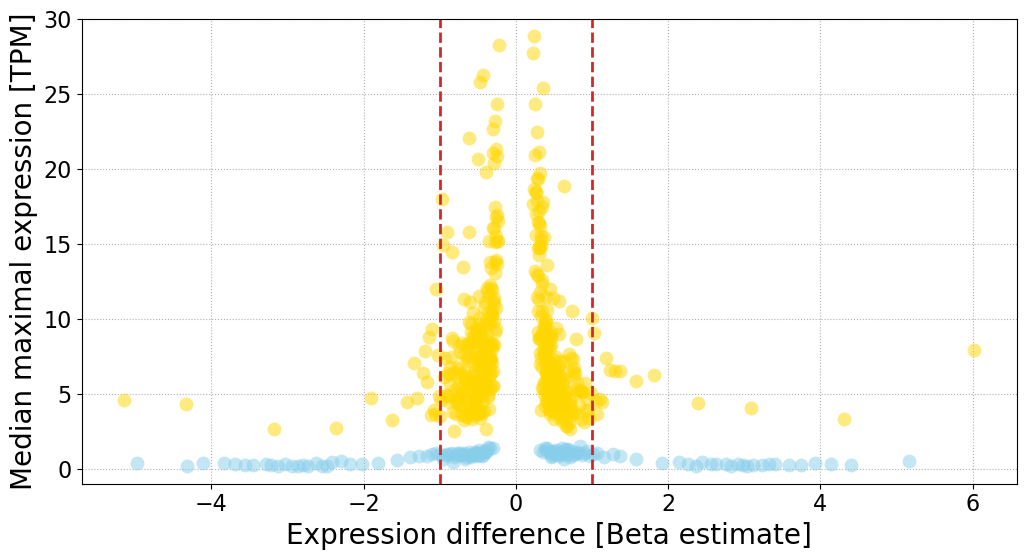

In [13]:
significant = df[df['pval'] < 0.05]
resolution = 10

wdf = significant[significant['max'] > 2]
wdf.sort_values(by='estimate', axis=0, inplace=True)
limit = wdf.shape[0]
intervals = numpy.clip(numpy.arange(0, limit+resolution, resolution), 0, limit)
x = []; y = []
for i in range(len(intervals) - 1):
    a = intervals[i]; b = intervals[i+1]
    mini = wdf.iloc[a:b, :]
    yi = numpy.median(mini['max'])
    xi = numpy.median(mini['estimate'])
    x.append(xi); y.append(yi)
matplotlib.pyplot.plot(x, y, 'o', color='gold', alpha=1/2, mec='none', ms=10)

#########

wdf = significant[significant['max'] < 2]
wdf.sort_values(by='estimate', axis=0, inplace=True)
limit = wdf.shape[0]
resolution = 25
intervals = numpy.clip(numpy.arange(0, limit+resolution, resolution), 0, limit)
x = []; y = []
for i in range(len(intervals) - 1):
    a = intervals[i]; b = intervals[i+1]
    mini = wdf.iloc[a:b, :]
    yi = numpy.median(mini['max'])
    xi = numpy.median(mini['estimate'])
    x.append(xi); y.append(yi)
matplotlib.pyplot.plot(x, y, 'o', color='skyblue', alpha=1/2, mec='none', ms=10)

########

matplotlib.pyplot.axvline(x=-1, lw=2, ls='--', color='tab:red')
matplotlib.pyplot.axvline(x=1, lw=2, ls='--', color='tab:red')

matplotlib.pyplot.ylim(-1, 30)
#matplotlib.pyplot.title('Max expression '
matplotlib.pyplot.xlabel('Expression difference [Beta estimate]')
matplotlib.pyplot.ylabel('Median maximal expression [TPM]')
matplotlib.pyplot.grid(ls=':', zorder=0)
matplotlib.pyplot.tight_layout()
matplotlib.pyplot.show()